# Transformer Notebook


## Section 1: Why Attention Is Not Enough
Attention allows tokens to communicate.
We still need a mechanism to transform information.
We still need stable training.

## Section 2: Layer Normalization
Implement normalization manually

In [9]:
import torch

x = torch.tensor([
    [1.0, 2.0, 3.0],
    [5.0, 10.0, 15.0]
])

mean = x.mean(dim=-1, keepdim=True)

variance = x.var(dim=-1, unbiased=False, keepdim=True)

normalized_output = (x - mean) / torch.sqrt(variance)

print("mean:\n", mean)
print("variance:\n", variance)
print("normalized_output:\n", normalized_output)

mean:
 tensor([[ 2.],
        [10.]])
variance:
 tensor([[ 0.6667],
        [16.6667]])
normalized_output:
 tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  0.0000,  1.2247]])


In [10]:
# Verify with
normalized_output.mean(dim=-1)
normalized_output.var(dim=-1, unbiased=False)

tensor([1.0000, 1.0000])

## Section 3: Exploring GELU
Compare ReLU and GELU

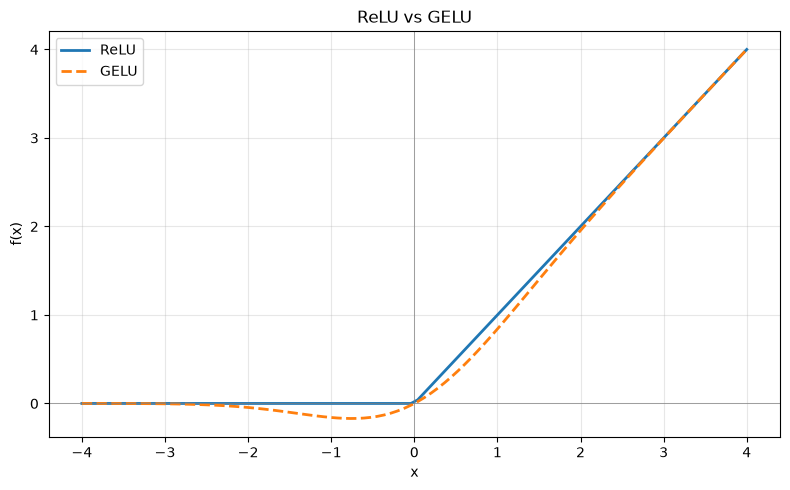

In [18]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-4, 4, 100)

relu = torch.relu(x)
gelu = torch.nn.functional.gelu(x)


plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), relu.numpy(), label="ReLU", linewidth=2)
plt.plot(x.numpy(), gelu.numpy(), label="GELU", linewidth=2, linestyle="--")

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.title("ReLU vs GELU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 4: Feed Forward Network
Review figure 4.10 in the book

In [14]:
# Create
input_shape = (2, 3, 768)

In [19]:
import torch.nn as nn

d_model = 768
d_ff = 3072

x = torch.randn(input_shape)

linear1 = nn.Linear(d_model, d_ff)
h = linear1(x)
print("After linear 1:", h.shape)

h = nn.functional.gelu(h)
print("After GELU:    ", h.shape)

linear2 = nn.Linear(d_ff, d_model)
out = linear2(h)
print("After linear 2:", out.shape)


After linear 1: torch.Size([2, 3, 3072])
After GELU:     torch.Size([2, 3, 3072])
After linear 2: torch.Size([2, 3, 768])


## Section 5: Residual Connections
Inspect output shapes using a toy network
Compare
 - With residual
 - Without residual

In [16]:
layer = nn.Sequential(
    nn.Linear(768, 3072),
    nn.GELU(),
    nn.Linear(3072, 768),
)

y = layer(x)
print("layer(x):", y.shape)

output = x + layer(x)
print("output:  ", output.shape)

layer(x): torch.Size([2, 3, 768])
output:   torch.Size([2, 3, 768])


## Section 6: Connecting Everything
This notebook has walked you through the following process, which is the blueprint for a TransformerBlock
 - Input
 - LayerNorm
 - Attention
 - Add Residual
 - LayerNorm
 - FeedForward
 - Add Residual
 - Output